## Exercise 2: Fed-Batch Penicillin Production

In this exercise, we will analyse the production of Penicillin by P. chrysogenum in a fed-batch reactor. We will derive the system equations, simulate the reactor over multiple cycles, and analyze the effects of substrate inhibition.

### a) Derivation of Differential Equations

In a fed-batch system, the volume is not constant. We must start with the fundamental mass balance:
**Rate of Accumulation = Rate In - Rate Out + Rate of Generation/Consumption**

**1. Volume Balance ($V$):**
Since there is a continuous feed at a flow rate $f_0$ and no withdrawal during the feeding phase:
$$\frac{dV}{dt} = f_0$$

**2. Biomass Balance ($X$):**
Total biomass in the tank is $X \cdot V$. Assuming no cells in the feed and neglecting cell maintenance:
$$\frac{d(XV)}{dt} = \mu X V$$
Applying the product rule: $V\frac{dX}{dt} + X\frac{dV}{dt} = \mu X V$
Substituting $\frac{dV}{dt} = f_0$ and dividing by $V$:
$$\frac{dX}{dt} = \mu X - \frac{f_0}{V}X$$

**3. Substrate Balance ($S$):**
Total substrate is $S \cdot V$. The substrate enters at concentration $S_0$ and is consumed for growth.
$$\frac{d(SV)}{dt} = f_0 S_0 - \frac{\mu X V}{Y_{X/S}}$$
$$V\frac{dS}{dt} + S\frac{dV}{dt} = f_0 S_0 - \frac{\mu X V}{Y_{X/S}}$$
Substituting $\frac{dV}{dt} = f_0$ and dividing by $V$:
$$\frac{dS}{dt} = \frac{f_0}{V}(S_0 - S) - \frac{\mu X}{Y_{X/S}}$$

**4. Product Balance ($P$):**
Total product is $P \cdot V$. The product is generated at a specific rate $q_p$.
$$\frac{d(PV)}{dt} = q_p X V$$
$$V\frac{dP}{dt} + P\frac{dV}{dt} = q_p X V$$
$$\frac{dP}{dt} = q_p X - \frac{f_0}{V}P$$

**5. Kinetic Model (Uncompetitive Substrate Inhibition):**
Based on the provided literature (Sivakumarmar et al., 1994.), substrate inhibition occurs at higher levels, often inducing high osmotic shock. For uncompetitive inhibition, the Haldane model (also referred to as Andrews and Noack) is the standard formulation:
$$\mu = \frac{\mu_m S}{K_S + S + \frac{S^2}{K_I}}$$

**Initial Conditions (at t=0):**
* $V(0) = 200$ L
* $X(0) = 30$ g/L
* $S(0) = 0$ g/L
* $P(0) = 0$ g/L

### b) Cycle Time

The tank starts at an initial volume of 200 L and reaches a maximum capacity of 800 L. 
The flow rate is a constant 50 L/h.

$$\text{Volume Added} = V_{max} - V_0 = 800 - 200 = 600 \text{ L}$$
$$\text{Cycle Time (t)} = \frac{\text{Volume Added}}{f_0} = \frac{600}{50} = 12 \text{ hours}$$

One cycle takes exactly 12 hours.

### c)  Time development of glucose and cells over 10 cycles

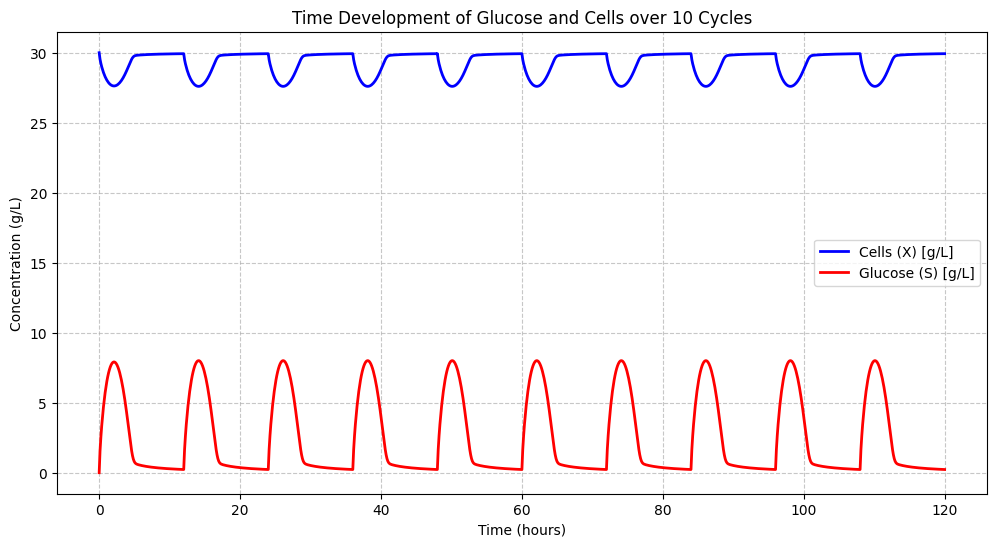

Total product removed over 10 cycles: 136.88 kg


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Parameters ---
f0 = 50.0      # L/h
V0_initial = 200.0 # L
V_max = 800.0  # L
V_removed = 600.0 # L
S0_feed = 100.0 # g/L
mu_m = 0.2     # 1/h
Ks = 0.50      # g/L
Ki = 50.0      # g/L
Yxs = 0.3      # g-cells/g-glucose
qp = 0.08      # g-product/g-cell/h

cycle_time = (V_max - V0_initial) / f0
num_cycles = 10

# --- ODE System ---
def fed_batch_system(t, y, S_feed):
    V, X, S, P = y
    
    # Haldane kinetics for uncompetitive inhibition
    mu = (mu_m * S) / (Ks + S + (S**2 / Ki))
    
    dV_dt = f0
    dX_dt = mu * X - (f0 / V) * X
    dS_dt = (f0 / V) * (S_feed - S) - (mu * X) / Yxs
    dP_dt = qp * X - (f0 / V) * P
    
    return [dV_dt, dX_dt, dS_dt, dP_dt]

# --- c) Simulation over 10 cycles ---
# Initial state: [V, X, S, P]
state = [V0_initial, 30.0, 0.0, 0.0]

time_all = []
V_all = []
X_all = []
S_all = []
P_all = []

total_product_removed_kg = 0.0

for cycle in range(num_cycles):
    t_span = [cycle * cycle_time, (cycle + 1) * cycle_time]
    t_eval = np.linspace(t_span[0], t_span[1], 100)
    
    sol = solve_ivp(fed_batch_system, t_span, state, t_eval=t_eval, args=(S0_feed,), method='LSODA')
    
    time_all.append(sol.t)
    V_all.append(sol.y[0])
    X_all.append(sol.y[1])
    S_all.append(sol.y[2])
    P_all.append(sol.y[3])
    
    # End of cycle values
    V_end = sol.y[0][-1]
    X_end = sol.y[1][-1]
    S_end = sol.y[2][-1]
    P_end = sol.y[3][-1]
    
    # Remove 600 L
    product_removed_grams = V_removed * P_end
    total_product_removed_kg += product_removed_grams / 1000.0
    
    # Reset state for next cycle (Concentrations remain the same, volume drops to 200 L)
    state = [V0_initial, X_end, S_end, P_end]

# Flatten arrays for plotting
time_all = np.concatenate(time_all)
X_all = np.concatenate(X_all)
S_all = np.concatenate(S_all)

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(time_all, X_all, label='Cells (X) [g/L]', color='blue', lw=2)
plt.plot(time_all, S_all, label='Glucose (S) [g/L]', color='red', lw=2)
plt.title('Time Development of Glucose and Cells over 10 Cycles')
plt.xlabel('Time (hours)')
plt.ylabel('Concentration (g/L)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print(f"Total product removed over 10 cycles: {total_product_removed_kg:.2f} kg")

Over 10 cycles, 136.88 kg of product are removed

### d) Substrate Inhibition Analysis

If we observe the substrate concentration $S$ in the plot above, it rises significantly in the early stages of each cycle (and progressively over multiple cycles). 

**Comparing Growth Rates:**
* **Without inhibition (Monod):** If $S$ is high (e.g., $S \gg K_S$), $\mu \approx \mu_m = 0.2/h$.
* **With inhibition (Haldane):** Because $K_I = 50$ g/L, when $S$ accumulates (for example, hitting 20 g/L or more), the $\frac{S^2}{K_I}$ term in the denominator becomes quite large. If $S = 20$ g/L, $\frac{S^2}{K_I} = \frac{400}{50} = 8$. This significantly increases the denominator, suppressing the specific growth rate $\mu$ well below 0.2 /h. 

**Risk of increasing the amount of substrate in the feed:**
If we increase the feed substrate concentration ($S_0$) or the flow rate, the rate at which substrate enters will greatly exceed the rate at which the initial biomass can consume it. This causes $S$ to rapidly accumulate in the reactor. Due to the uncompetitive inhibition, the elevated $S$ further inhibits cellular growth (lowering $\mu$). This creates a cascading failure: slower growth means even less substrate is consumed, leading to further toxic accumulation of substrate and eventual biological washout or process failure.

To clearly see if (and how much) the substrate inhibits the system, we can plot the specific growth rate ($\mu$) as a function of substrate concentration ($S$) for both the uninhibited Monod model and the uncompetitive Haldane model.

<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:13: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:17: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:12: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:13: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:15: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences wil

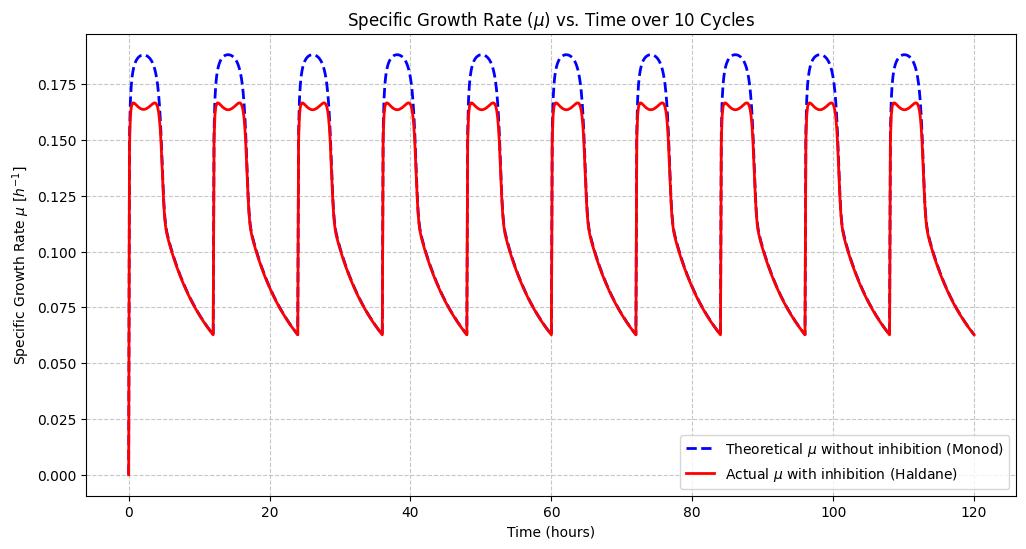

In [6]:
# --- d) Plotting Growth Rate over 10 Cycles ---

# We use the S_all array (glucose concentration over time) from the part c) simulation

# Calculate theoretical Monod growth rate (no inhibition) over time
mu_monod_time = (mu_m * S_all) / (Ks + S_all)

# Calculate actual Haldane growth rate (with uncompetitive inhibition) over time
mu_haldane_time = (mu_m * S_all) / (Ks + S_all + (S_all**2 / Ki))

plt.figure(figsize=(12, 6))
plt.plot(time_all, mu_monod_time, label='Theoretical $\mu$ without inhibition (Monod)', linestyle='--', color='blue', lw=2)
plt.plot(time_all, mu_haldane_time, label='Actual $\mu$ with inhibition (Haldane)', color='red', lw=2)

plt.title('Specific Growth Rate ($\mu$) vs. Time over 10 Cycles')
plt.xlabel('Time (hours)')
plt.ylabel('Specific Growth Rate $\mu$ [$h^{-1}$]')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### e) Advantage of Fed-Batch vs. Batch Culture

The primary advantage of a fed-batch culture for substrate-inhibited systems is concentration control. 
If this were a batch culture, we would have to add the entire required amount of glucose at $t=0$ to reach the desired final biomass. This massive initial concentration would immediately trigger severe substrate inhibition, effectively stalling growth from the very beginning. By using a fed-batch operation, we slowly "drip-feed" the glucose. This allows the cells to consume the substrate roughly at the same rate it is added, keeping the bulk liquid concentration of glucose relatively low and avoiding the inhibitory effects, while still delivering a large total mass of substrate over the entire process.

### f) Optimization of the Reactor Cycle


We can extract the absolute maximum value and the corresponding optimal feed substrate concentration ($S_0$).

--- Optimization Results ---
Optimal Feed Substrate Concentration (S0): 136.67 g/L
Maximum Production Rate (10th cycle): 1610.4945 g/h

Note: The ideal feed S0 balances bringing in enough mass to create product,
while avoiding pushing the internal reactor concentration 'S' far beyond 5.00 g/L,
where severe Haldane inhibition begins.


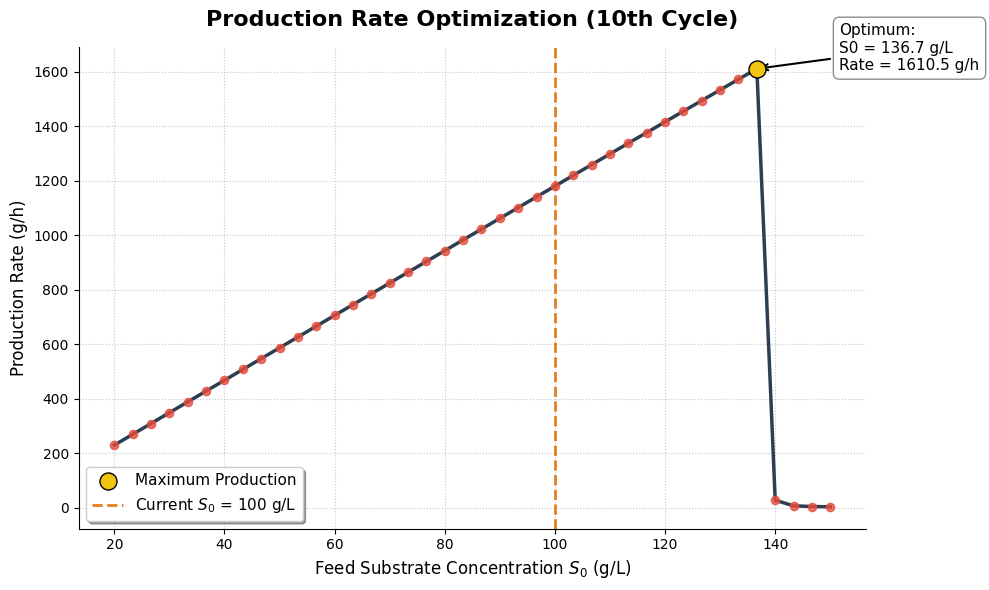

In [9]:
# --- f) Optimization of the Reactor Cycle ---

def calculate_production_rate(S0_val):
    state = [V0_initial, 30.0, 0.0, 0.0]
    total_product = 0.0
    
    for cycle in range(num_cycles):
        t_span = [cycle * cycle_time, (cycle + 1) * cycle_time]
        sol = solve_ivp(fed_batch_system, t_span, state, args=(S0_val,), method='LSODA', max_step=0.5)
        
        P_end = sol.y[3][-1]
        
        # Only record the mass removed in the 10th cycle for the rate calculation, 
        # as per "mass of product removed from 10th cycle / cycle time"
        if cycle == 9: 
            mass_10th_cycle = V_removed * P_end
            
        state = [V0_initial, sol.y[1][-1], sol.y[2][-1], P_end]
        
    return mass_10th_cycle / cycle_time # g/h

# Sweep feed substrate concentrations
S0_range = np.linspace(20, 150, 40)
production_rates = []

for s in S0_range:
    rate = calculate_production_rate(s)
    production_rates.append(rate)

# --- Extracting the Optimal Parameters ---
optimal_index = np.argmax(production_rates)
optimal_S0 = S0_range[optimal_index]
max_production_rate = production_rates[optimal_index]

print("--- Optimization Results ---")
print(f"Optimal Feed Substrate Concentration (S0): {optimal_S0:.2f} g/L")
print(f"Maximum Production Rate (10th cycle): {max_production_rate:.4f} g/h")

# Calculate the theoretical optimal steady-state substrate concentration in the reactor
S_opt_reactor = np.sqrt(Ks * Ki)

print(f"\nNote: The ideal feed S0 balances bringing in enough mass to create product,")
print(f"while avoiding pushing the internal reactor concentration 'S' far beyond {S_opt_reactor:.2f} g/L,")
print(f"where severe Haldane inhibition begins.")

# --- Upgraded Plotting ---
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Main trend line and markers
ax.plot(S0_range, production_rates, color='#2c3e50', linewidth=2.5, zorder=3)
ax.scatter(S0_range, production_rates, color='#e74c3c', s=35, zorder=4, alpha=0.8)

# 2. Highlight the maximum point
ax.scatter([optimal_S0], [max_production_rate], color='#f1c40f', s=150, edgecolor='black', zorder=5, label='Maximum Production')

# Add an arrow pointing to the exact maximum value
ax.annotate(f'Optimum:\nS0 = {optimal_S0:.1f} g/L\nRate = {max_production_rate:.1f} g/h',
            xy=(optimal_S0, max_production_rate), 
            xytext=(optimal_S0 + 15, max_production_rate - 5), # Offset the text
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
            fontsize=11, 
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.9))

# 3. Vertical line for current S0
ax.axvline(x=100, color='#e67e22', linestyle='--', linewidth=2, label=r'Current $S_0$ = 100 g/L', zorder=2)

# 4. Typography and Labels
ax.set_title('Production Rate Optimization (10th Cycle)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel(r'Feed Substrate Concentration $S_0$ (g/L)', fontsize=12)
ax.set_ylabel('Production Rate (g/h)', fontsize=12)

# 5. Clean up the grid and borders
ax.grid(True, linestyle=':', alpha=0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Legend positioning
ax.legend(loc='lower left', frameon=True, fontsize=11, shadow=True)

plt.tight_layout()
plt.show()